In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from utils.calculador_angulos import calculate_angle, extract_angles_from_landmarks
from utils.graphs import media_movel, detectar_repeticoes_exercicio, plotar_grafico_angulos

# 1- Análise dados Flexão

In [ ]:
# Carregando dados de flexão
df_flexao = pd.read_csv('files_output/1_min_flexao_full_5fps_flexao.csv')
df_flexao

,frame,processed_frame,timestamp_s,model,processing_time_ms,landmark_idx,landmark_name,x,y,z,visibility,presence,passed_filter,exercise
0,0,0,0.0,unknown,103.707314,0,Nose,0.459077,0.435132,-0.312750,0.999988,0.999986,True,flexao
1,0,0,0.0,unknown,103.707314,1,Left Eye (Inner),0.465022,0.424862,-0.284498,0.999978,0.999956,True,flexao
2,0,0,0.0,unknown,103.707314,2,Left Eye,0.466640,0.424740,-0.284394,0.999954,0.999942,True,flexao
3,0,0,0.0,unknown,103.707314,3,Left Eye (Outer),0.468016,0.424601,-0.284299,0.999972,0.999923,True,flexao
4,0,0,0.0,unknown,103.707314,4,Right Eye (Inner),0.456273,0.423066,-0.332812,0.999989,0.999977,True,flexao
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9400,1710,285,57.0,unknown,56.828976,28,Right Ankle,0.485421,0.804235,0.363989,0.541251,0.999796,True,flexao
9401,1710,285,57.0,unknown,56.828976,29,Left Heel,0.869614,0.769929,-0.053025,0.951812,0.999151,True,flexao
9402,1710,285,57.0,unknown,56.828976,30,Right Heel,0.525913,0.811594,0.376794,0.672732,0.999771,True,flexao
9403,1710,285,57.0,unknown,56.828976,31,Left Foot Index,0.842612,0.820032,-0.220251,0.933408,0.998712,True,flexao


In [ ]:
# Transformar os landmarks em ângulos
df_angles_flexao = extract_angles_from_landmarks(df_flexao)
df_angles_flexao

,frame,timestamp_s,exercise,right_cotovelo,right_cotovelo_visibility_weight,left_cotovelo,left_cotovelo_visibility_weight,right_ombro,right_ombro_visibility_weight,left_ombro,left_ombro_visibility_weight,right_joelho,right_joelho_visibility_weight,left_joelho,left_joelho_visibility_weight,right_quadril,right_quadril_visibility_weight,left_quadril,left_quadril_visibility_weight
0,0,0.0,flexao,128.584808,0.998011,139.259521,0.529754,27.397871,0.999150,24.300436,0.753622,169.697235,0.894572,157.981949,0.665154,173.705383,0.950193,175.946945,0.765950
1,6,0.2,flexao,121.153587,0.997991,126.631485,0.544121,26.008823,0.999046,22.457495,0.755084,169.260345,0.900872,159.688416,0.667081,163.339676,0.952746,178.812698,0.769118
2,12,0.4,flexao,119.729301,0.997885,124.277649,0.568839,20.476686,0.999019,21.540239,0.763016,167.736481,0.908827,166.848907,0.674791,152.901764,0.956316,179.325943,0.774068
3,18,0.6,flexao,121.487328,0.997684,120.263672,0.584948,18.508518,0.998980,19.302473,0.767115,172.097092,0.915936,164.991394,0.683698,151.328003,0.959620,176.548660,0.779814
4,24,0.8,flexao,124.188545,0.997506,128.551895,0.604017,11.297976,0.998909,28.815027,0.772947,170.088318,0.922533,170.836975,0.692699,141.970261,0.962725,177.220596,0.785382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
280,1686,56.2,flexao,164.583160,0.521630,173.100388,0.986476,74.161568,0.738527,76.917709,0.994260,170.096024,0.536684,171.809250,0.918714,166.015442,0.731795,166.627075,0.950305
281,1692,56.4,flexao,168.675064,0.525665,169.748856,0.987075,84.469620,0.740243,90.747726,0.994593,78.255730,0.564044,176.610886,0.926546,80.515869,0.747060,158.313705,0.955048
282,1698,56.6,flexao,167.293961,0.540542,178.800720,0.987849,94.568420,0.748294,104.918297,0.994976,48.210514,0.586454,173.696167,0.933811,26.332941,0.758450,152.670334,0.959513
283,1704,56.8,flexao,171.753220,0.550229,175.091873,0.988391,100.722198,0.753965,108.664879,0.995218,56.309628,0.606748,171.141602,0.940355,28.381361,0.768837,149.040192,0.963535


## Análise ângulos dos cotovelos e joelhos durante a flexão

In [ ]:
# Gerando media móvel para suavizar os movimentos
df_angles_flexao_mm3= media_movel(df_angles_flexao, janela=3)
df_angles_flexao_mm3 = df_angles_flexao_mm3[df_angles_flexao_mm3['timestamp_s'] <= 30]

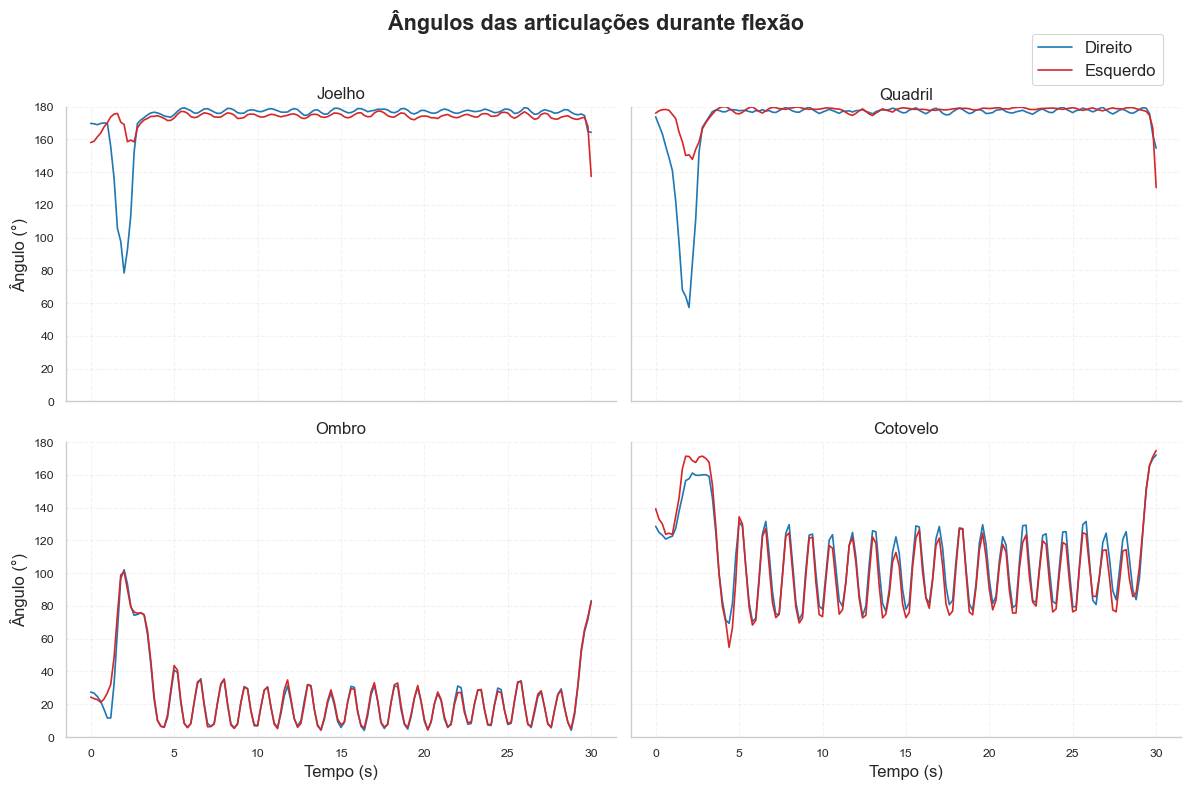

In [ ]:
# Plotando os ângulos das articulações durante a flexão
plotar_grafico_angulos(df_angles_flexao_mm3, 'Ângulos das articulações durante flexão', articulacoes=('joelho', 'quadril', 'ombro', 'cotovelo'), fonte=12)

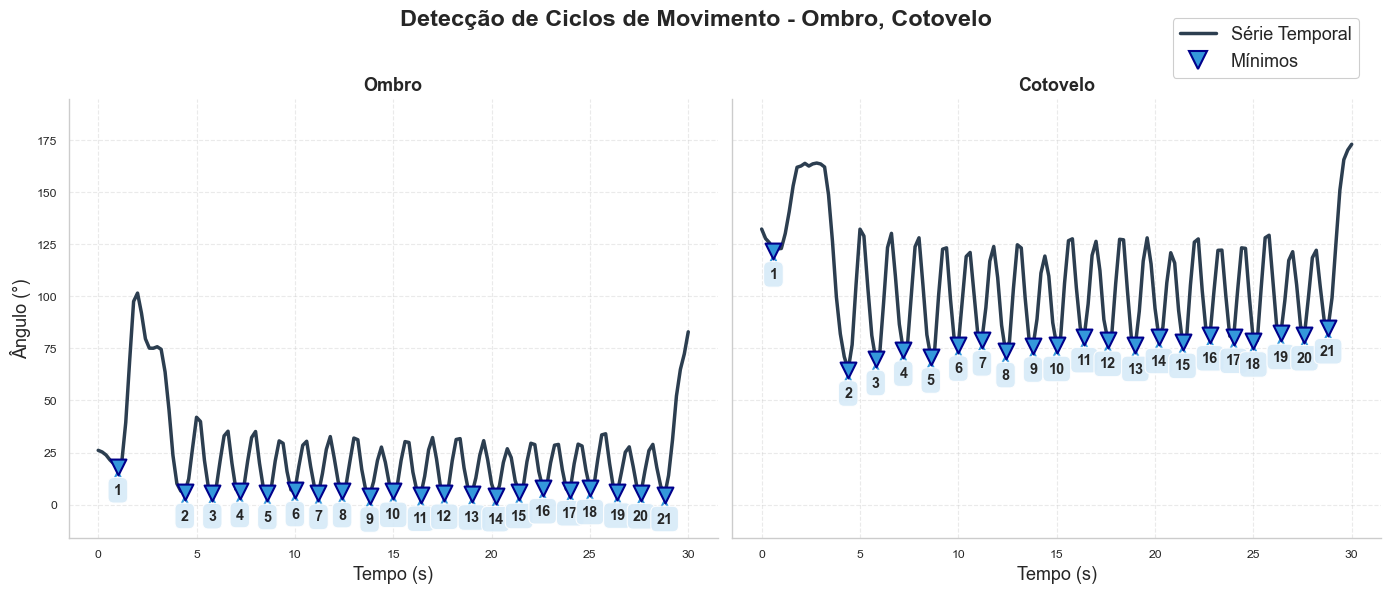

In [ ]:
# Utilizando método de detecção de repetições baseado em vales para contagem das repetições de flexão
detectar_repeticoes_exercicio(
    df_angles_flexao_mm3,
    articulacoes=['ombro', 'cotovelo'],
    tipo_deteccao='vales',
    fontsize=13
)

# 2- Análise dados Agachamento

In [ ]:
# Carregando dados de agachamento
df_agachamento = pd.read_csv('files_output/2_min_agachamento_full_5fps_agachamento.csv')
df_agachamento

,frame,processed_frame,timestamp_s,model,processing_time_ms,landmark_idx,landmark_name,x,y,z,visibility,presence,passed_filter,exercise
0,0,0,0.0,full,117.153406,0,Nose,0.666536,0.456063,0.016429,0.999134,0.999648,True,agachamento
1,0,0,0.0,full,117.153406,1,Left Eye (Inner),0.664845,0.443492,0.041082,0.998299,0.999473,True,agachamento
2,0,0,0.0,full,117.153406,2,Left Eye,0.663011,0.442395,0.040946,0.997703,0.999451,True,agachamento
3,0,0,0.0,full,117.153406,3,Left Eye (Outer),0.660651,0.441109,0.040856,0.998684,0.999395,True,agachamento
4,0,0,0.0,full,117.153406,4,Right Eye (Inner),0.662927,0.443361,-0.043401,0.998670,0.999558,True,agachamento
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29266,5316,886,177.2,full,91.052771,28,Right Ankle,0.617585,0.930344,-0.137959,0.987676,0.994421,True,agachamento
29267,5316,886,177.2,full,91.052771,29,Left Heel,0.602672,0.923288,0.432787,0.603585,0.984643,True,agachamento
29268,5316,886,177.2,full,91.052771,30,Right Heel,0.589472,0.951892,-0.138576,0.975081,0.990505,True,agachamento
29269,5316,886,177.2,full,91.052771,31,Left Foot Index,0.704106,0.924245,0.337296,0.679852,0.986353,True,agachamento


In [ ]:
# Transformar os landmarks em ângulos
df_angles_agachamento = extract_angles_from_landmarks(df_agachamento)
df_angles_agachamento

,frame,timestamp_s,exercise,right_cotovelo,right_cotovelo_visibility_weight,left_cotovelo,left_cotovelo_visibility_weight,right_ombro,right_ombro_visibility_weight,left_ombro,left_ombro_visibility_weight,right_joelho,right_joelho_visibility_weight,left_joelho,left_joelho_visibility_weight,right_quadril,right_quadril_visibility_weight,left_quadril,left_quadril_visibility_weight
0,0,0.0,agachamento,174.871063,0.987753,170.758682,0.427994,94.881927,0.995007,93.751190,0.699644,150.655762,0.973120,154.374283,0.431824,138.079391,0.977645,140.585342,0.682253
1,6,0.2,agachamento,172.316818,0.988287,171.951553,0.429501,91.277374,0.995158,92.336212,0.699387,154.900421,0.974537,156.383835,0.439210,143.523315,0.978970,143.650360,0.684697
2,12,0.4,agachamento,168.092224,0.987948,168.856003,0.430568,88.463470,0.994974,88.667328,0.699240,160.427002,0.974423,157.616623,0.448978,152.041367,0.979508,148.065277,0.689352
3,18,0.6,agachamento,172.340027,0.988063,168.281738,0.440571,89.869965,0.994961,87.535477,0.701789,162.453156,0.973787,160.681839,0.457349,158.449249,0.980101,151.469467,0.694483
4,24,0.8,agachamento,175.401291,0.988364,175.057861,0.448329,91.461243,0.995121,89.946930,0.704432,162.328659,0.974305,162.432404,0.471682,158.741455,0.980962,156.151123,0.701957
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
882,5292,176.4,agachamento,177.420395,0.965530,173.910599,0.434831,114.195892,0.992327,116.490372,0.710889,123.182617,0.994501,130.651733,0.654165,94.508064,0.996299,94.915695,0.800184
883,5298,176.6,agachamento,178.763916,0.968336,173.710571,0.434535,103.083572,0.992919,104.845230,0.710083,141.037796,0.994566,147.332550,0.646054,122.505913,0.996331,125.628456,0.795560
884,5304,176.8,agachamento,171.930252,0.971106,171.202850,0.437380,85.092468,0.993515,92.805077,0.709443,144.679184,0.994714,155.396072,0.646557,141.009735,0.996425,142.981567,0.794409
885,5310,177.0,agachamento,146.913223,0.972743,161.849655,0.430529,37.579388,0.993700,41.664417,0.706297,151.780579,0.994001,160.764130,0.644486,161.174835,0.996131,163.498672,0.791972


## Análise ângulos dos joelhos e quadril durante o agachamento

In [ ]:
# Gerando media móvel para suavizar os movimentos
df_angles_agachamento_mm3= media_movel(df_angles_agachamento, janela=3)
df_angles_agachamento_mm3 = df_angles_agachamento_mm3[df_angles_agachamento_mm3['timestamp_s'] <= 60]

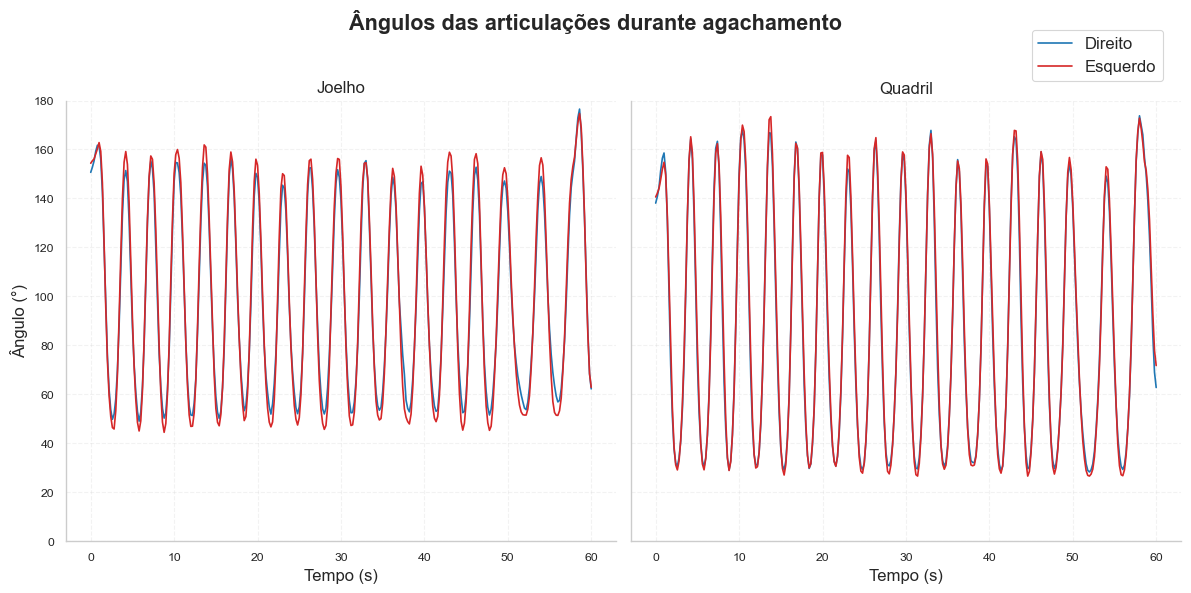

In [ ]:
# Plotando os ângulos das articulações de joelho e quadril durante o agachamento
plotar_grafico_angulos(df_angles_agachamento_mm3, 'Ângulos das articulações durante agachamento', articulacoes=['joelho', 'quadril'], fonte = 12)

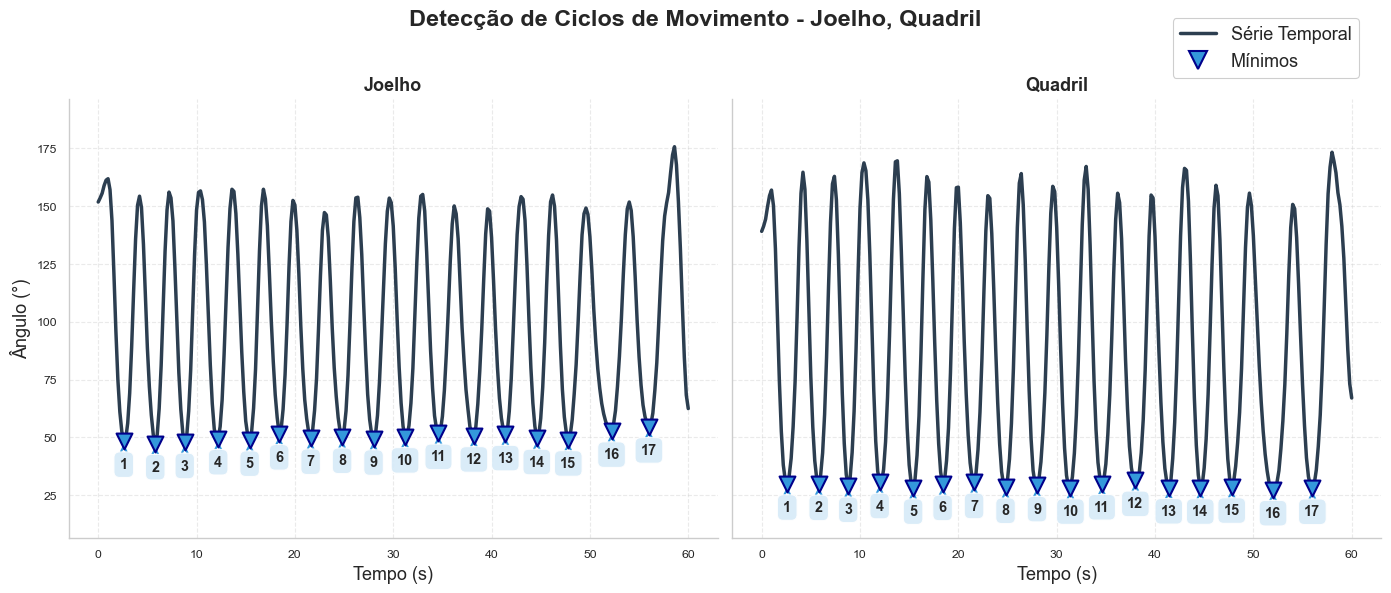

In [ ]:
# Utilizando método de detecção de repetições baseado em vales para contagem das repetições de agachamento
detectar_repeticoes_exercicio(
    df_angles_agachamento_mm3,
    articulacoes=['joelho', 'quadril'],
    tipo_deteccao='vales',
    fontsize=13
)

# 3- Análise dados Rosca Direta

In [ ]:
# Carregando dados de rosca direta
df_rosca = pd.read_csv('files_output\\2_min_rosca_direta_full_5fps_rosca_biceps.csv')
df_rosca

,frame,processed_frame,timestamp_s,model,processing_time_ms,landmark_idx,landmark_name,x,y,z,visibility,presence,passed_filter,exercise
0,0,0,0.0,full,118.573427,0,Nose,0.624339,0.440246,-0.010436,0.998963,0.999064,True,rosca_biceps
1,0,0,0.0,full,118.573427,1,Left Eye (Inner),0.616982,0.429392,0.014296,0.997450,0.998730,True,rosca_biceps
2,0,0,0.0,full,118.573427,2,Left Eye,0.615667,0.429143,0.014269,0.997099,0.998626,True,rosca_biceps
3,0,0,0.0,full,118.573427,3,Left Eye (Outer),0.614024,0.428888,0.014332,0.997708,0.998478,True,rosca_biceps
4,0,0,0.0,full,118.573427,4,Right Eye (Inner),0.612444,0.429056,-0.054389,0.998196,0.999049,True,rosca_biceps
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19894,3612,602,120.4,full,42.149782,28,Right Ankle,0.535403,0.953828,-0.283861,0.944775,0.981641,True,rosca_biceps
19895,3612,602,120.4,full,42.149782,29,Left Heel,0.523958,0.933573,0.362183,0.562871,0.963719,True,rosca_biceps
19896,3612,602,120.4,full,42.149782,30,Right Heel,0.514786,0.972706,-0.295832,0.915740,0.966771,True,rosca_biceps
19897,3612,602,120.4,full,42.149782,31,Left Foot Index,0.636521,0.950084,0.267892,0.662191,0.968833,True,rosca_biceps


In [ ]:
# Transformar os landmarks em ângulos
df_angles_rosca = extract_angles_from_landmarks(df_rosca)
df_angles_rosca

,frame,timestamp_s,exercise,right_cotovelo,right_cotovelo_visibility_weight,left_cotovelo,left_cotovelo_visibility_weight,right_ombro,right_ombro_visibility_weight,left_ombro,left_ombro_visibility_weight,right_joelho,right_joelho_visibility_weight,left_joelho,left_joelho_visibility_weight,right_quadril,right_quadril_visibility_weight,left_quadril,left_quadril_visibility_weight
0,0,0.0,rosca_biceps,142.350632,0.983887,148.606232,0.364092,0.236563,0.992838,1.499200,0.669648,179.638992,0.952463,174.950058,0.565740,168.665894,0.975517,166.321396,0.756459
1,6,0.2,rosca_biceps,143.467804,0.983171,153.820251,0.363002,0.019782,0.992481,2.758892,0.669428,179.767609,0.952207,171.758698,0.562095,169.282944,0.975454,170.637589,0.754936
2,12,0.4,rosca_biceps,146.574615,0.982151,147.459793,0.362130,2.014894,0.991966,0.367441,0.669192,178.634552,0.947919,168.288025,0.556574,169.772141,0.973592,174.724808,0.753490
3,18,0.6,rosca_biceps,145.500336,0.981890,145.268906,0.362098,2.722107,0.991967,1.165333,0.669056,175.382584,0.949156,131.564285,0.560925,171.995926,0.974353,168.624313,0.757610
4,24,0.8,rosca_biceps,145.836929,0.980213,150.820526,0.361254,2.046027,0.991627,4.054343,0.668648,174.798920,0.945077,159.766968,0.557629,170.005005,0.972600,174.187546,0.757915
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
598,3588,119.6,rosca_biceps,145.710007,0.973958,143.309433,0.376583,36.460606,0.990843,29.004539,0.677224,177.572144,0.954580,175.486801,0.615797,170.319473,0.977188,168.546387,0.783482
599,3594,119.8,rosca_biceps,131.448029,0.975375,140.245636,0.377227,27.081007,0.991424,11.115085,0.678150,178.244186,0.958399,178.881088,0.621016,160.409760,0.979206,167.388840,0.786068
600,3600,120.0,rosca_biceps,115.075264,0.976151,141.038101,0.378618,15.827371,0.991748,5.098813,0.678935,176.239838,0.960783,173.697281,0.618121,167.416458,0.980627,175.462738,0.785161
601,3606,120.2,rosca_biceps,119.209251,0.977271,139.492584,0.382871,11.867986,0.992138,0.362077,0.680621,178.854294,0.963001,173.543533,0.617853,176.610703,0.981920,177.361053,0.785950


## Análise ângulos articulações durante o exercício rosca direta

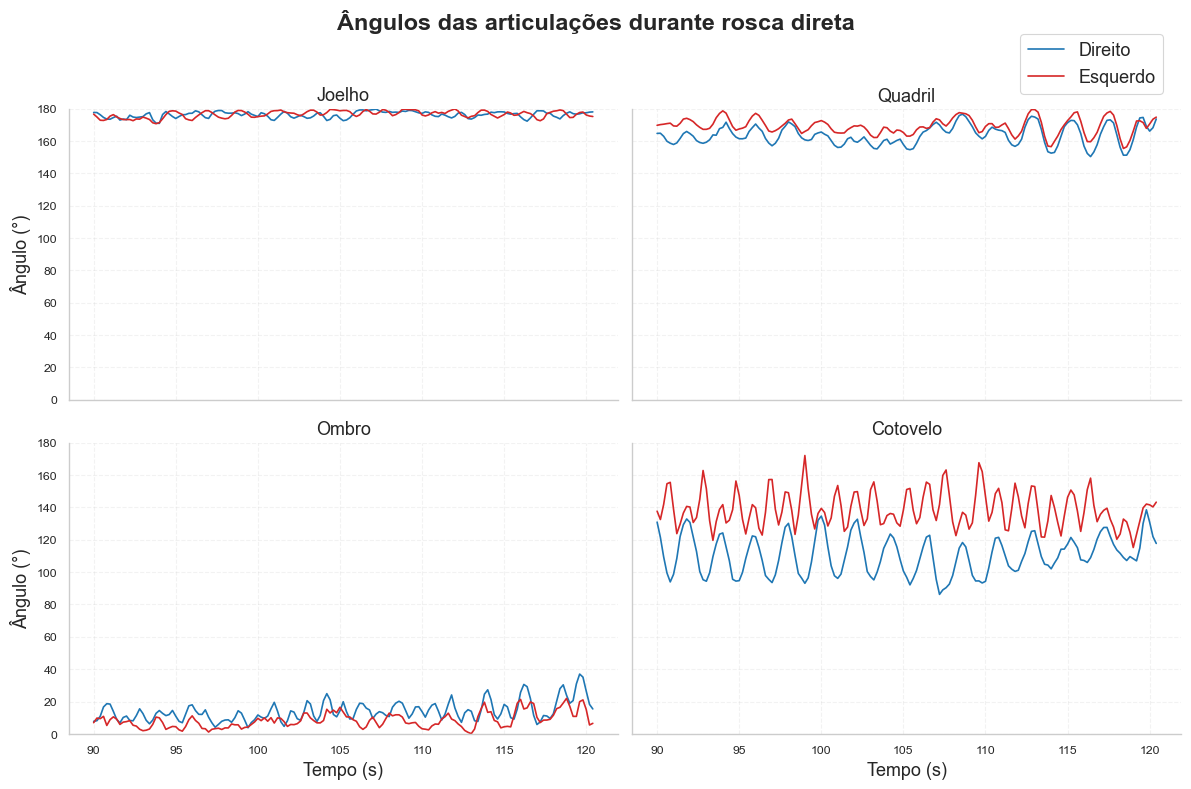

In [ ]:
# Gerando media móvel para suavizar os movimentos
df_angles_rosca_mm3= media_movel(df_angles_rosca, janela=3)
# df_angles_rosca_mm3 = df_angles_rosca_mm3[(df_angles_rosca_mm3['timestamp_s']  >= 52) & (df_angles_rosca_mm3['timestamp_s'] <= 85)]
# df_angles_rosca_mm3 = df_angles_rosca_mm3[(df_angles_rosca_mm3['timestamp_s']  <= 50)]
df_angles_rosca_mm3 = df_angles_rosca_mm3[(df_angles_rosca_mm3['timestamp_s']  >= 90)]

# Plotando os ângulos das articulações de Joelho e Quadril, Ombro, Cotovelo durante a rosca direta
plotar_grafico_angulos(df_angles_rosca_mm3, 'Ângulos das articulações durante rosca direta', fonte = 13)


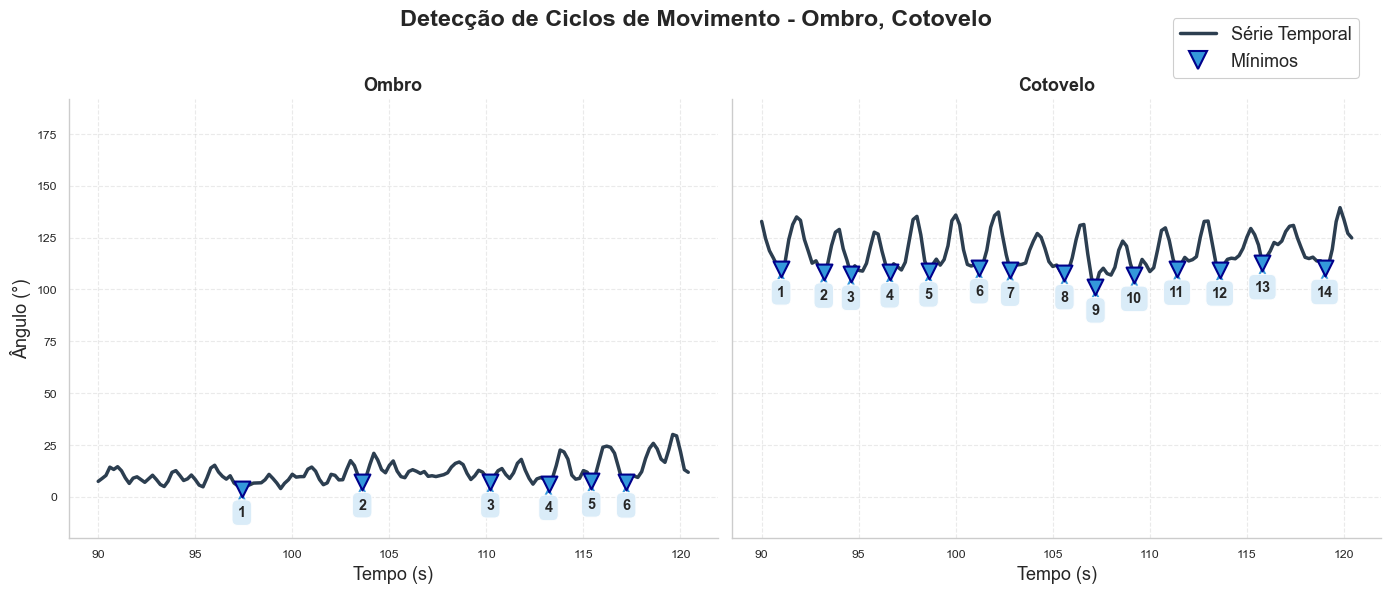

In [ ]:
# Utilizando método de detecção de repetições baseado em vales para contagem das repetições de rosca direta
detectar_repeticoes_exercicio(
    df_angles_rosca_mm3,
    articulacoes=[ 'ombro', 'cotovelo'],
    tipo_deteccao='vales',
    prominence_vales=10,
    fontsize=13
)

# 3- Análise dados Descanso

In [ ]:
# Carregando dados de descanso
df_descanso = pd.read_csv('files_output/2_min_descanso_full_5fps_descanso.csv')
df_descanso

,frame,processed_frame,timestamp_s,model,processing_time_ms,landmark_idx,landmark_name,x,y,z,visibility,presence,passed_filter,exercise
0,0,0,0.0,full,121.725082,0,Nose,0.673387,0.713010,-0.323280,0.999923,0.999983,True,descanso
1,0,0,0.0,full,121.725082,1,Left Eye (Inner),0.693016,0.711047,-0.314178,0.999813,0.999976,True,descanso
2,0,0,0.0,full,121.725082,2,Left Eye,0.694996,0.710166,-0.314337,0.999883,0.999976,True,descanso
3,0,0,0.0,full,121.725082,3,Left Eye (Outer),0.697096,0.709105,-0.314493,0.999826,0.999977,True,descanso
4,0,0,0.0,full,121.725082,4,Right Eye (Inner),0.691319,0.709918,-0.368688,0.999829,0.999977,True,descanso
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23557,4284,714,142.8,full,75.824499,28,Right Ankle,0.614524,0.927282,-0.234590,0.982340,0.991370,True,descanso
23558,4284,714,142.8,full,75.824499,29,Left Heel,0.594048,0.925913,0.226453,0.586735,0.985855,True,descanso
23559,4284,714,142.8,full,75.824499,30,Right Heel,0.591856,0.947165,-0.240835,0.965254,0.984979,True,descanso
23560,4284,714,142.8,full,75.824499,31,Left Foot Index,0.704363,0.929061,0.109588,0.695993,0.986439,True,descanso


In [ ]:
# Transformar os landmarks em ângulos
df_angles_descanso = extract_angles_from_landmarks(df_descanso)
df_angles_descanso

,frame,timestamp_s,exercise,right_cotovelo,right_cotovelo_visibility_weight,left_cotovelo,left_cotovelo_visibility_weight,right_ombro,right_ombro_visibility_weight,left_ombro,left_ombro_visibility_weight,right_joelho,right_joelho_visibility_weight,left_joelho,left_joelho_visibility_weight,right_quadril,right_quadril_visibility_weight,left_quadril,left_quadril_visibility_weight
0,0,0.0,descanso,144.029205,0.991124,165.533447,0.572297,99.985451,0.997439,97.560112,0.749035,158.480774,0.997666,82.817360,0.803922,133.462891,0.998842,29.924885,0.863386
1,6,0.2,descanso,143.130737,0.991294,174.696289,0.578919,60.396629,0.997484,96.198494,0.752759,154.993164,0.997372,107.955246,0.803119,130.468033,0.998659,43.493919,0.864441
2,12,0.4,descanso,154.031555,0.990417,178.824631,0.613313,38.651173,0.996900,59.141354,0.771863,151.553391,0.993687,156.711258,0.800028,103.789986,0.996379,84.901970,0.866466
3,18,0.6,descanso,130.025208,0.990920,157.952454,0.648569,45.106201,0.996793,48.320667,0.791599,142.278961,0.986759,178.628967,0.814729,108.702950,0.993856,94.227554,0.877469
4,24,0.8,descanso,119.194702,0.978501,158.065964,0.662113,90.848122,0.986947,80.406059,0.794918,142.913864,0.981316,139.187149,0.832869,91.874153,0.990012,118.128593,0.889487
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
709,4260,142.0,descanso,124.656570,0.979099,112.989586,0.380800,18.255945,0.993781,9.189813,0.681445,149.998856,0.988124,152.021637,0.595638,109.945763,0.994616,109.823692,0.766687
710,4266,142.2,descanso,132.039902,0.980782,114.912407,0.393671,37.274025,0.994240,26.419275,0.685186,145.697220,0.989073,151.884262,0.605950,118.692917,0.995006,120.901527,0.770959
711,4272,142.4,descanso,149.417801,0.982469,134.811920,0.400289,50.689770,0.994694,38.698341,0.686667,152.788651,0.989639,152.179810,0.608661,141.017929,0.995150,137.628418,0.770165
712,4278,142.6,descanso,158.358414,0.983951,144.778671,0.404285,52.094448,0.995048,40.871613,0.688093,158.843964,0.989541,156.894928,0.610264,159.510223,0.994958,155.915100,0.770127


## Análise ângulos articulações durante o exercício rosca direta

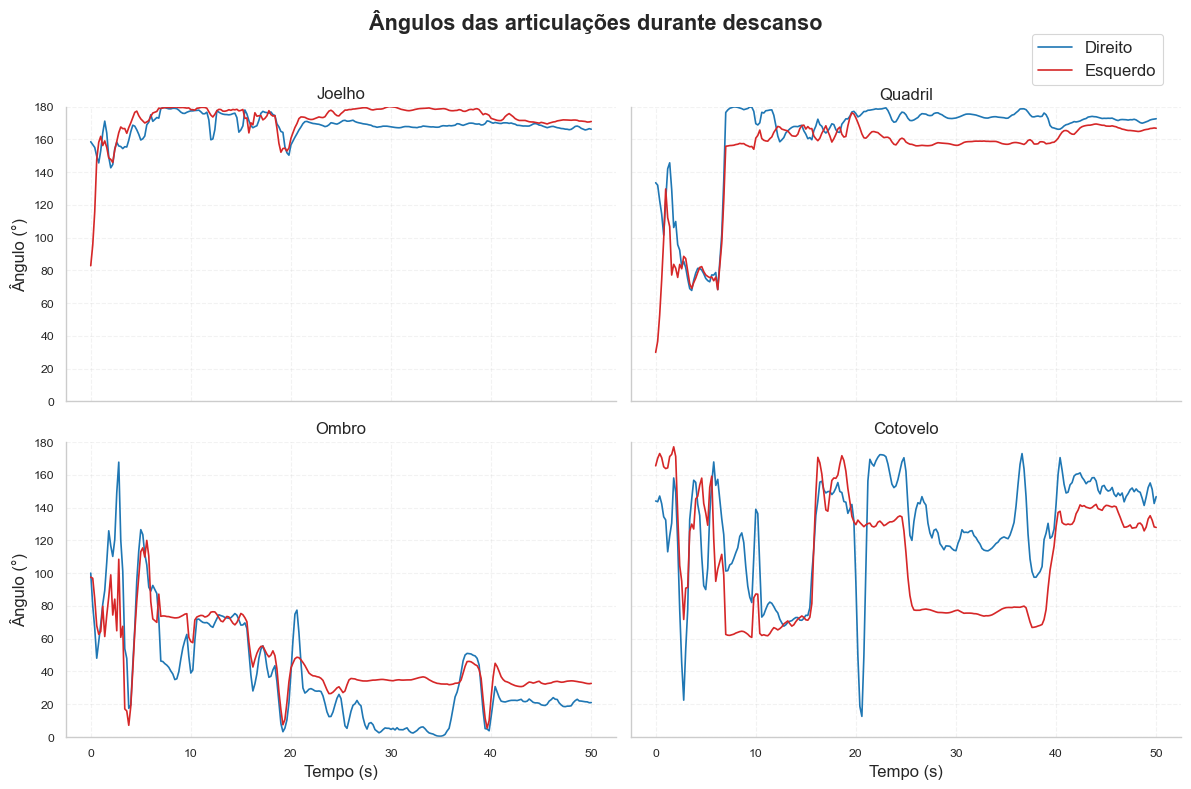

In [ ]:
# Gerando media móvel para suavizar os movimentos
df_angles_descanso_mm3= media_movel(df_angles_descanso, janela=3)
df_angles_descanso_mm3 = df_angles_descanso_mm3[df_angles_descanso_mm3['timestamp_s'] <= 50]

# Plotando os ângulos das articulações durante descanso
plotar_grafico_angulos(df_angles_descanso_mm3, 'Ângulos das articulações durante descanso', fonte = 12)


# Distribuição dos ângulos por exercício

In [ ]:
df_angles_rosca_mm3['exercicio'] = 'Rosca Direta'
df_angles_agachamento_mm3['exercicio'] = 'Agachamento'
df_angles_flexao_mm3['exercicio'] = 'Flexão'
df_angles_descanso_mm3['exercicio'] = 'Descanso'


data = pd.concat([df_angles_rosca_mm3, df_angles_agachamento_mm3, df_angles_flexao_mm3, df_angles_descanso_mm3], ignore_index=True)
data

In [ ]:
# Visualizar distribuições com melhor contraste
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

# Cores mais distintas para cada exercício
colors = plt.cm.Set2(np.linspace(0, 1, len(data['exercise'].unique())))
exercise_colors = {ex: colors[i] for i, ex in enumerate(data['exercise'].unique())}

angle_columns = ['right_cotovelo', 'left_cotovelo','right_ombro', 'left_ombro', 'right_joelho', 'left_joelho','right_quadril', 'left_quadril']
for idx, col in enumerate(angle_columns):
    for exercise in sorted(data['exercise'].unique()):
        subset = data[data['exercise'] == exercise][col]
        axes[idx].hist(subset, alpha=0.8, label=exercise, bins=9, 
                      color=exercise_colors[exercise], edgecolor='black', linewidth=0.2)
    
    axes[idx].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Ângulo (°)', fontsize=11)
    axes[idx].set_ylabel('Frequência', fontsize=11)
    axes[idx].legend(fontsize=10, loc='upper right', framealpha=0.95)
    axes[idx].grid(alpha=0.4, linestyle='--')

plt.suptitle('Distribuição de Ângulos Articulares por Exercício', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()
